In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.io as pio
import numpy as np
from pathlib import Path
import requests
import time
import urllib3
import random
import kaleido

from pytrends.request import TrendReq
from scipy.stats import median_abs_deviation, norm
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from prophet.plot import add_changepoints_to_plot
from prophet.plot import plot_plotly, plot_components_plotly
np.set_printoptions(suppress=True)

In [ ]:
# Config

out = Path("/home/question/Downloads/SingalFLow/")
out.mkdir(exist_ok=True)

SPIKE_THRESHOLD   = 1.5
BUILD_THRESHOLD   = 0.8
COLLAPSE_THRESHOLD = -1.0

In [ ]:
# keyword_list = input("Enter Keyword here: ")
keyword_list = ["relaxation"]
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [ ]:
MAX_RETRIES = 11
WAIT_SECONDS = 2
retries = 0
def fetch_trends(keyword_list, gprop=""):
    """
    Fetches Google Trends data for a list of keywords.
    gprop: "" (web), "youtube", or "news"
    Returns a raw wide dataframe.
    """
    
    pytrends = TrendReq(
        tz=360,
        timeout=(10, 25),
        requests_args={"verify": False},
        hl = "fr"   # France 🇫🇷
    )

    retries = 0
    while retries < MAX_RETRIES:

        try:
            print(f"\nSending request: {keyword_list}")
            pytrends.build_payload(
                keyword_list,
                timeframe="today 12-m",
                gprop=gprop
            )
            iot = pytrends.interest_over_time()
            if iot.empty:
                raise ValueError("Empty dataframe")
            print("✅ Success")
            time.sleep(3)
            return iot

        except Exception as e:
            retries += 1
            err = str(e)

            if "429" in err:
                wait = (WAIT_SECONDS * (2 ** retries)) + random.uniform(0, 5)
                print(f"⚠️ 429 Rate limit. Waiting {wait:.0f}s")
                time.sleep(wait)

            elif "500" in err:
                wait = (WAIT_SECONDS * (2 ** retries)) + random.uniform(0, 5)
                print(f"⚠️ 500 Google error. Retry in {wait:.0f}s")
                time.sleep(wait)

            elif "400" in err:
                print("⚠️ 400 Bad request. Skipping.")
                print("❌ Unknown error:", e)
                raise ValueError("Wrong Keyword")
            
            elif "response is empty" in err.lower() or "empty" in err.lower():
                print("⚠️ Empty response. Skipping.")
                return pd.DataFrame()

            else:
                wait = WAIT_SECONDS
                print("❌ Unknown error:", e)
                print(f"Retrying in {wait}s")
                time.sleep(wait)

    print("❌ Max retries reached.")
    return pd.DataFrame()

In [ ]:
web_df = fetch_trends(keyword_list, gprop="")
print(f" Shape of df: {web_df.shape}")


Sending request: ['relaxation']
⚠️ 429 Rate limit. Waiting 5s

Sending request: ['relaxation']
⚠️ 429 Rate limit. Waiting 12s

Sending request: ['relaxation']
⚠️ 429 Rate limit. Waiting 19s

Sending request: ['relaxation']
⚠️ 429 Rate limit. Waiting 37s

Sending request: ['relaxation']


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✅ Success
 Shape of df: (53, 2)


In [ ]:
youtube_df = fetch_trends(keyword_list, gprop="youtube")
print(f" Shape of df: {youtube_df.shape}")


Sending request: ['relaxation']
⚠️ 429 Rate limit. Waiting 7s

Sending request: ['relaxation']
⚠️ 429 Rate limit. Waiting 11s

Sending request: ['relaxation']
⚠️ 429 Rate limit. Waiting 19s

Sending request: ['relaxation']


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✅ Success
 Shape of df: (53, 2)


In [ ]:
news_df = fetch_trends(keyword_list, gprop="news")
print(f" Shape of df: {news_df.shape}")


Sending request: ['relaxation']


/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✅ Success
 Shape of df: (53, 2)


In [ ]:
df_list =  [web_df, youtube_df , news_df] 
type(df_list)

list

In [ ]:
print(f" Shape of df: {web_df.shape}")
print(f" Shape of df: {youtube_df.shape}")
print(f" Shape of df: {news_df.shape}")
if web_df.empty and youtube_df.empty and news_df.empty:
    raise ValueError("All dataframes are empty. Stopping execution.")

 Shape of df: (53, 2)
 Shape of df: (53, 2)
 Shape of df: (53, 2)


In [ ]:
web_df.head()

,relaxation,isPartial
date,,
2025-06-01,25,False
2025-06-08,26,False
2025-06-15,26,False
2025-06-22,28,False
2025-06-29,27,False


In [ ]:
def clean_df(df):
    keyword_col = [c for c in df.columns if c != "isPartial"][0]
    df_clean = df.reset_index()
    if "isPartial" in df.columns:
        df_clean = df_clean.drop(columns=["isPartial"])
    if "index" in df.columns:
        df_clean = df_clean.drop(columns=["index"])
    df_clean = df_clean.rename(columns={"date": "ds", keyword_col: "y"})
    return df_clean

# usage - make sure you pass both arguments
web_clean     = clean_df(web_df)
youtube_clean = clean_df(youtube_df)
news_clean    = clean_df(news_df)
web_clean.head()

,ds,y
0,2025-06-01,25
1,2025-06-08,26
2,2025-06-15,26
3,2025-06-22,28
4,2025-06-29,27


In [ ]:
def melt_and_combine():
    web_clean["source"]     = "web"
    youtube_clean["source"] = "youtube"
    news_clean["source"]    = "news"

    combined = pd.concat([web_clean, youtube_clean, news_clean], ignore_index=True)

    combined = combined.sort_values("ds").reset_index(drop=True)
    return combined

In [37]:
combined_df = melt_and_combine()
combined_df["ds"] = pd.to_datetime(combined_df["ds"])
combined_df.head()

,ds,y,source
0,2025-06-01,25,web
1,2025-06-01,73,youtube
2,2025-06-01,0,news
3,2025-06-08,26,web
4,2025-06-08,71,youtube


In [45]:
# -----------
# 2. Velocity 
# ------------
def add_velocity(df):
    """
    Expects a df with ds and y columns.
    Adds short (4 weeks) and long (12 weeks) velocity and their zscores.
    """
    df = df.copy()

    df["velocity_short"] = df["y"].rolling(4).mean().diff() # 4 weeks = 1 Month 
    df["velocity_long"]  = df["y"].rolling(12).mean().diff() # 12 weeks = 1 quarter 

    df["velocity_short_zscore"] = robust_zscore(df["velocity_short"])
    df["velocity_long_zscore"]  = robust_zscore(df["velocity_long"])

    df["regime"] = df.apply(
    classify_regime, axis=1,
    spike_threshold=SPIKE_THRESHOLD,
    build_threshold=BUILD_THRESHOLD,
    collapse_threshold=COLLAPSE_THRESHOLD
)

    return df

analysis_df = add_velocity(combined_df)
analysis_df.tail()

,ds,y,source,velocity_short,velocity_long,velocity_short_zscore,velocity_long_zscore,regime
154,2026-05-24,36,web,-5.25,-3.750000,-0.583333,-1.666667,Quiet
155,2026-05-24,58,youtube,7.25,0.166667,0.805556,0.074074,Building
156,2026-05-31,49,youtube,1.25,-0.666667,0.138889,-0.296296,Quiet
157,2026-05-31,46,web,4.00,1.833333,0.444444,0.814815,Quiet
158,2026-05-31,46,news,2.50,-4.083333,0.277778,-1.814815,Quiet


In [46]:
# -----------
# 2. Z score using Median instead of Mean  
# ------------
def robust_zscore(series):
    series = series.astype(float)
    median = series.median()
    mad = max(median_abs_deviation(series, nan_policy="omit"), 1e-6) 
    return (series - median) / mad
    
    # Compute the Median Absolute Deviation (MAD), a robust measure of spread
    # similar to standard deviation but less sensitive to outliers.
    # Ensure MAD is never too close to zero.
    # max(..., 1e-6) sets a minimum value of 0.000001.
    #
    # Why?
    # - If all values in the series are identical (or nearly identical),
    #   MAD can become 0.
    # - Later calculations may divide by MAD.
    # - Division by 0 would cause errors or extremely unstable values.
    #
    # Using a tiny floor value (1e-6) prevents numerical instability.

analysis_df["zscore"] = robust_zscore(analysis_df["y"])
analysis_df.head()

,ds,y,source,velocity_short,velocity_long,velocity_short_zscore,velocity_long_zscore,regime,zscore
0,2025-06-01,25,web,NaN,NaN,NaN,NaN,Insufficient Data,-0.769231
1,2025-06-01,73,youtube,NaN,NaN,NaN,NaN,Insufficient Data,1.076923
2,2025-06-01,0,news,NaN,NaN,NaN,NaN,Insufficient Data,-1.730769
3,2025-06-08,26,web,NaN,NaN,NaN,NaN,Insufficient Data,-0.730769
4,2025-06-08,71,youtube,11.5,NaN,1.277778,NaN,Building,1.000000


In [53]:
def classify_regime(row, spike_threshold=SPIKE_THRESHOLD,
                         build_threshold=BUILD_THRESHOLD,
                         collapse_threshold=COLLAPSE_THRESHOLD):
    sz = row["velocity_short_zscore"]
    lz = row["velocity_long_zscore"]

    if pd.isna(sz):
        return "Insufficient Data"

    crossover = (sz - lz) if pd.notna(lz) else 0

    if sz > spike_threshold and crossover >= 0:
        return "Spike"
    elif sz > build_threshold and crossover >= 0:
        return "Building"
    elif sz < collapse_threshold or (pd.notna(lz) and crossover < -1 and lz > 0):  # was hardcoded -1.5
        return "Collapsing"
    else:
        return "Quiet"

analysis_df["regime"] = analysis_df.apply(classify_regime, axis=1)
analysis_df.head()

,ds,y,source,velocity_short,velocity_long,velocity_short_zscore,velocity_long_zscore,regime,zscore
0,2025-06-01,25,web,NaN,NaN,NaN,NaN,Insufficient Data,-0.769231
1,2025-06-01,73,youtube,NaN,NaN,NaN,NaN,Insufficient Data,1.076923
2,2025-06-01,0,news,NaN,NaN,NaN,NaN,Insufficient Data,-1.730769
3,2025-06-08,26,web,NaN,NaN,NaN,NaN,Insufficient Data,-0.730769
4,2025-06-08,71,youtube,11.5,NaN,1.277778,NaN,Building,1.000000


In [54]:
# -------------------------
# Step 1 — prepare input
# -------------------------
def prepare_prophet_input(df, weights={"web": 0.5, "youtube": 0.3, "news": 0.2}):
    df = df.copy()
    df["weight"]     = df["source"].map(weights)
    df["y_weighted"] = df["y"] * df["weight"]

    prophet_df = (
        df
        .groupby("ds")["y_weighted"]
        .sum()
        .reset_index()
        .rename(columns={"y_weighted": "y"})
        .dropna()
    )
    return prophet_df


# -------------------------
# Step 2 — fit and forecast
# -------------------------
def run_prophet(prophet_df, periods=13, freq="W"):
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        changepoint_prior_scale=0.05
    )
    model.fit(prophet_df)
    future   = model.make_future_dataframe(periods=periods, freq=freq)
    forecast = model.predict(future)
    return model, forecast

# -------------------------
# Testing
# -------------------------
prophet_df          = prepare_prophet_input(combined_df)
model, forecast = run_prophet(prophet_df)

16:38:05 - cmdstanpy - INFO - Chain [1] start processing
16:38:05 - cmdstanpy - INFO - Chain [1] done processing


In [55]:
# -------------------------
# 7.1 All three signals
# -------------------------
def plot_signals(web_clean, youtube_clean, news_clean):
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(web_clean["ds"],     web_clean["y"],     color="steelblue",  linewidth=2, label="Web Search")
    ax.plot(youtube_clean["ds"], youtube_clean["y"], color="tomato",     linewidth=2, label="YouTube")
    ax.plot(news_clean["ds"],    news_clean["y"],    color="goldenrod",  linewidth=2, label="News")

    ax.set_title(f"Signal Comparison of Keyword: {keyword_list[0]}", fontsize=14, fontweight="bold")
    ax.set_ylabel("Weighted Trend Score")
    ax.set_xlabel("Date")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(out / f"Signal Comparison of Keyword: {keyword_list[0]}", 
                dpi=300, bbox_inches="tight"
    )
    plt.show()


# plot_signals(web_clean, youtube_clean, news_clean)

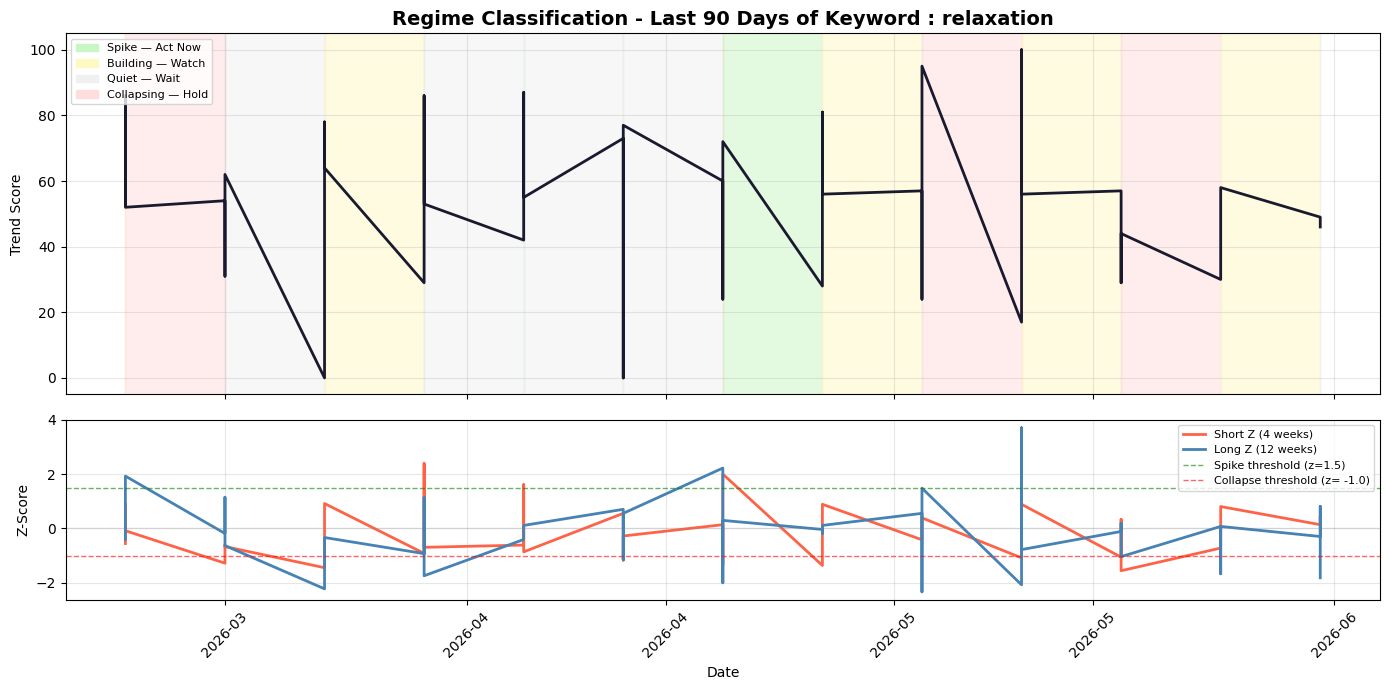

In [58]:
# -------------------------
# 7.2 Plot Regime
# -------------------------
def plot_regime(analysis_df):

    # Keep only last 90 days for plotting
    cutoff_date = analysis_df["ds"].max() - pd.Timedelta(days=90)
    regime_df = analysis_df[analysis_df["ds"] >= cutoff_date].copy()

    regime_colors = {
        "Spike":             "#c8f7c5",
        "Building":          "#fef9c3",
        "Quiet":             "#f0f0f0",
        "Collapsing":        "#fdd",
        "Insufficient Data": "#ffffff"
    }

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(14, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # Shade background by regime
    for i in range(len(regime_df) - 1):

        regime = regime_df["regime"].iloc[i]

        ax1.axvspan(
            regime_df["ds"].iloc[i],
            regime_df["ds"].iloc[i + 1],
            color=regime_colors.get(regime, "#ffffff"),
            alpha=0.5
        )

    # Main trend
    ax1.plot(
        regime_df["ds"],
        regime_df["y"],
        color="#1a1a2e",
        linewidth=2,
        label="Trend Score"
    )

    ax1.set_ylabel("Trend Score")
    ax1.set_title(
        f"Regime Classification - Last 90 Days of Keyword : {keyword_list[0]}",
        fontsize=14,
        fontweight="bold"
    )

    ax1.grid(alpha=0.3)

    # Z-scores
    ax2.plot(
        regime_df["ds"],
        regime_df["velocity_short_zscore"],
        color="tomato",
        linewidth=2,
        label="Short Z (4 weeks)"
    )

    ax2.plot(
        regime_df["ds"],
        regime_df["velocity_long_zscore"],
        color="steelblue",
        linewidth=2,
        label="Long Z (12 weeks)"
    )

    ax2.axhline(
        y=SPIKE_THRESHOLD,
        color="green",
        linestyle="--",
        alpha=0.6,
        linewidth=1,
        label=f"Spike threshold (z={SPIKE_THRESHOLD})"
    )

    ax2.axhline(
        y=COLLAPSE_THRESHOLD,
        color="red",
        linestyle="--",
        alpha=0.6,
        linewidth=1,
        label= f"Collapse threshold (z= {COLLAPSE_THRESHOLD})"
    )

    ax2.axhline(
        y=0,
        color="gray",
        linestyle="-",
        alpha=0.2,
        linewidth=1
    )

    ax2.set_ylabel("Z-Score")
    ax2.set_xlabel("Date")
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

    # Regime legend
    patches = [
        mpatches.Patch(color="#c8f7c5", label="Spike — Act Now"),
        mpatches.Patch(color="#fef9c3", label="Building — Watch"),
        mpatches.Patch(color="#f0f0f0", label="Quiet — Wait"),
        mpatches.Patch(color="#fdd",    label="Collapsing — Hold"),
    ]

    ax1.legend(handles=patches, loc="upper left", fontsize=8)

    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(out / f"Regime Classification - Last 90 Days of Keyword : {keyword_list[0]}", 
                dpi=300, bbox_inches="tight"
    )
    plt.show()

plot_regime(analysis_df)

In [59]:

# -------------------------
# 7.3 Prophet forecast
# -------------------------
def plot_forecast(analysis_df, forecast_df):

    fig, ax = plt.subplots(figsize=(14, 5))

    # Historical
    ax.plot(
        analysis_df["ds"],
        analysis_df["y"],
        color="steelblue",
        linewidth=2,
        label="Historical"
    )

    # Forecast
    ax.plot(
        forecast_df["ds"],
        forecast_df["yhat"],
        color="tomato",
        linewidth=2,
        linestyle="--",
        label="Forecast"
    )

    # Confidence interval
    ax.fill_between(
        forecast_df["ds"],
        forecast_df["yhat_lower"],
        forecast_df["yhat_upper"],
        color="tomato",
        alpha=0.15,
        label="Confidence Interval"
    )

    # Forecast start line
    cutoff = analysis_df["ds"].max()

    ax.axvline(
        x=cutoff,
        color="gray",
        linestyle="--",
        alpha=0.5,
        label="Forecast Start"
    )

    # Dynamic forecast horizon
    forecast_days = (
        forecast_df["ds"].max() - cutoff
    ).days

    ax.set_title(
        f"Trend Forecast - Next {forecast_days} Days of Keyword : {keyword_list[0]}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_ylabel("Trend Score")
    ax.set_xlabel("Date")

    ax.legend()
    ax.grid(alpha=0.3)

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y-%m")
    )

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(out / f"Trend Forecast - Next {forecast_days} Days of Keyword : {keyword_list[0]}", 
                dpi=300, bbox_inches="tight"
    )
    plt.show()

# plot_forecast(prophet_df, forecast_only)

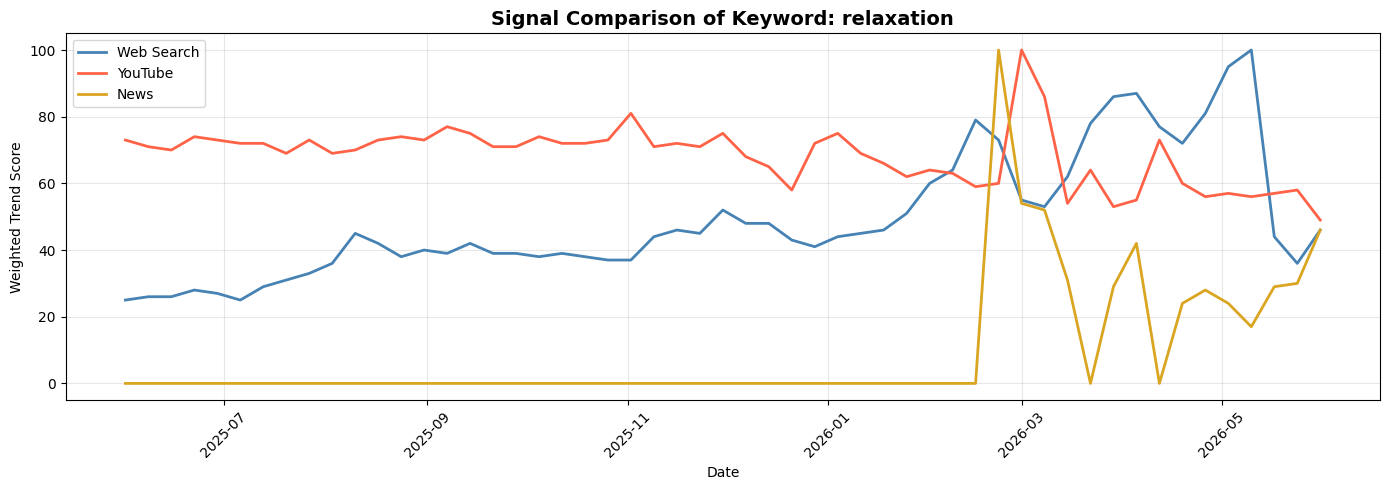

In [61]:
plot_signals(web_clean, youtube_clean, news_clean)

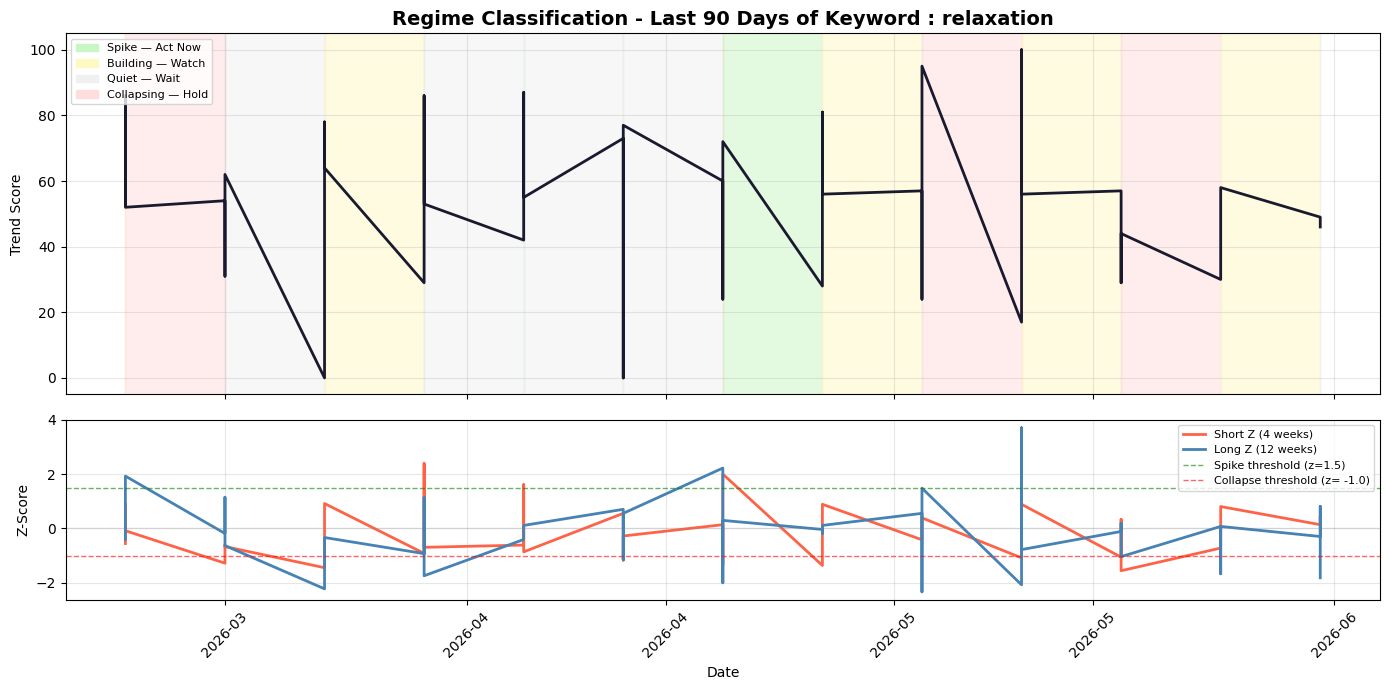

In [63]:
plot_regime(analysis_df)

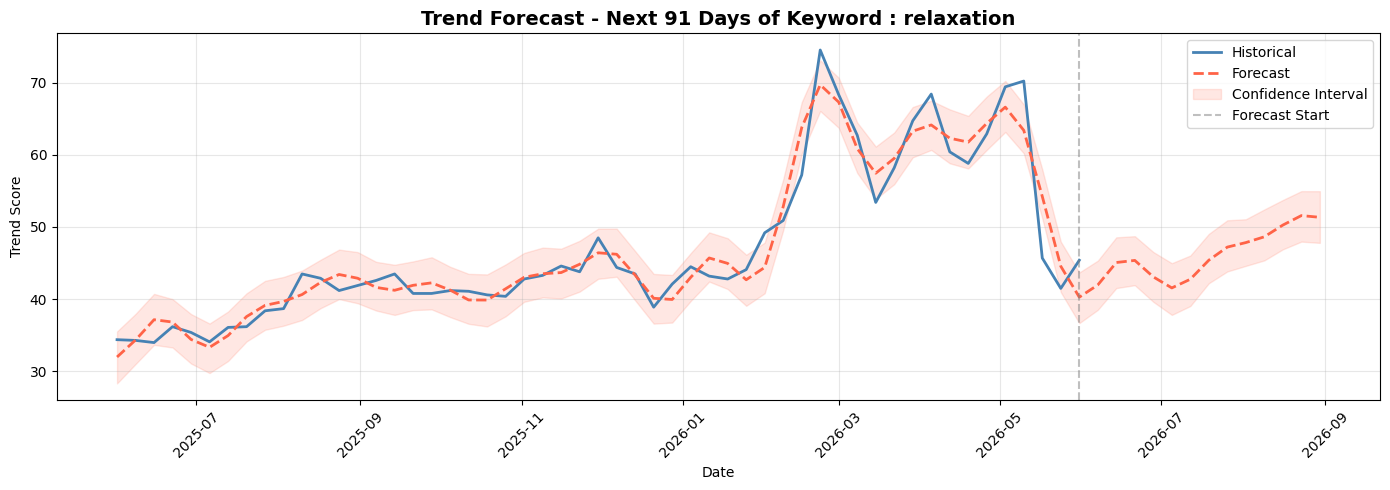

In [ ]:
plot_forecast(prophet_df, forecast_only)

In [ ]:
def plot_forecast_interactive(model, forecast):
    fig = plot_plotly(model, forecast)
    fig.update_layout(title=f"Forecast for {keyword_list[0]}", xaxis_title="Date", yaxis_title="Trend Score")
    file_path = out / f"Forecast_for_{keyword_list[0]}.html"
    fig.write_html(file_path)          
    fig.show()

def plot_components_interactive(model, forecast):
    fig = plot_components_plotly(model, forecast)
    file_path = out / f"Seasonality_for_{keyword_list[0]}.html"
    fig.write_html(file_path)          
    fig.show()

def plot_changepoints(model, forecast, df):
    fig = model.plot(forecast)
    add_changepoints_to_plot(
        fig.gca(), 
        model, 
        forecast,      
        trend=False    
    )
    plt.title("Changepoints")
    file_path = out / f"Changepoints_for_{keyword_list[0]}.png"
    plt.savefig(file_path)
    plt.show()

# -------------------------
# Testing
# -------------------------
# plot_forecast_interactive(model, forecast)
# plot_components_interactive(model, forecast)
# plot_changepoints(model, forecast, prophet_df)

In [ ]:
plot_forecast_interactive(model, forecast)

In [ ]:
plot_components_interactive(model, forecast)

/home/question/Documents/CS/jupkernel/lib/python3.12/site-packages/plotly/io/_json.py:558: UserWarning: Discarding nonzero nanoseconds in conversion.
  obj = obj.to_pydatetime()


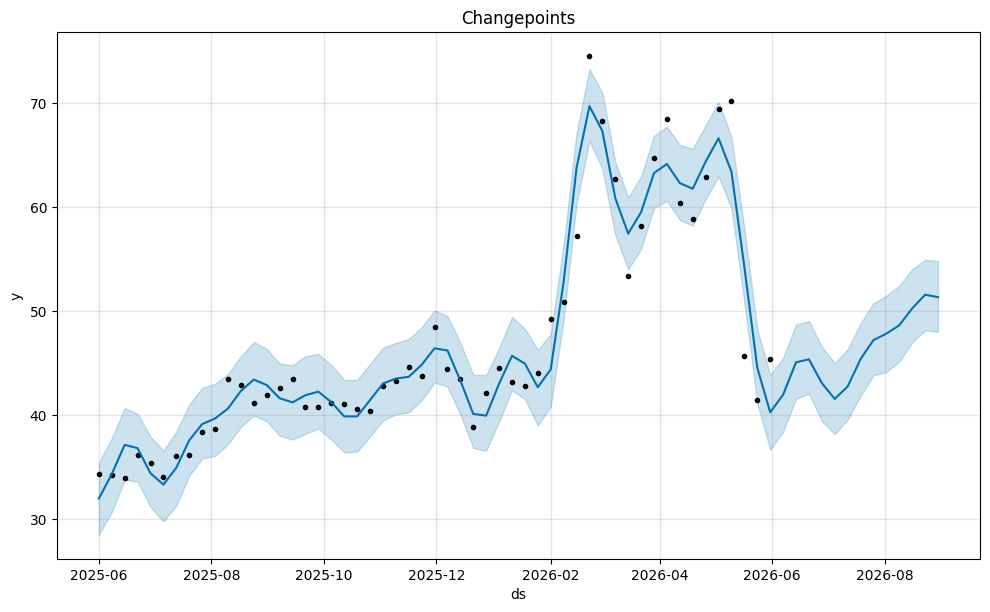

In [ ]:
plot_changepoints(model, forecast, prophet_df)

In [ ]:
from pytrends.request import TrendReq
import pandas as pd
import time
import random

MAX_RETRIES = 5
WAIT_SECONDS = 3

def fetch_related(keyword, geo="FR"):
    """
    Fetch Google Trends related queries (top + rising) for a keyword.
    Returns dict with DataFrames or empty dict on failure.
    """

    pytrends = TrendReq(hl='fr', tz=360)
    retries = 0

    while retries < MAX_RETRIES:
        try:
            print(f"\nRequesting: {keyword}")

            pytrends.build_payload([keyword], geo=geo, timeframe='today 12-m')
            related = pytrends.related_queries()

            # safer extraction
            if not related or keyword not in related:
                raise ValueError("No data returned")

            data = related.get(keyword, {})
            top_df = data.get("top")
            rising_df = data.get("rising")

            if top_df is None and rising_df is None:
                raise ValueError("Empty top & rising")

            print("✅ Success")

            return {
                "top": top_df,
                "rising": rising_df
            }

        except Exception as e:
            retries += 1
            err = str(e)
            print(f"Error {retries}/{MAX_RETRIES}: {err}")

            if "429" in err:
                wait = WAIT_SECONDS * (2 ** retries) + random.uniform(0, 3)
                print(f"Rate limit → waiting {wait:.1f}s")
                time.sleep(wait)

            elif "500" in err:
                wait = WAIT_SECONDS * (2 ** retries)
                print(f"Server error → retrying in {wait:.1f}s")
                time.sleep(wait)

            elif "400" in err:
                print("Bad request → invalid keyword")
                return {"top": None, "rising": None}

            elif "empty" in err.lower():
                print("No related queries found")
                return {"top": None, "rising": None}

            else:
                print("Unknown error → retrying")
                time.sleep(WAIT_SECONDS)

    print("❌ Max retries reached")
    return {"top": None, "rising": None}

result = fetch_related(keyword_list[0])

top_queries = result["top"]
rising_queries = result["rising"]
top = top_queries[:4]
rising = rising_queries[:4]

print(f"Top related queries: {top}")
print(f"Rising related queries {rising}")


Requesting: relaxation
Error 1/5: The request failed: Google returned a response with code 429
Rate limit → waiting 7.2s

Requesting: relaxation
Error 2/5: The request failed: Google returned a response with code 429
Rate limit → waiting 13.2s

Requesting: relaxation
Error 3/5: The request failed: Google returned a response with code 429
Rate limit → waiting 24.8s

Requesting: relaxation
Error 4/5: The request failed: Google returned a response with code 429
Rate limit → waiting 50.3s

Requesting: relaxation
✅ Success
                      query  value
0                   musique    100
1        relaxation musique     97
2     musique de relaxation     29
3  musique douce relaxation     28
                               query  value
0  relaxation musculaire progressive     70
1   musique de détente et relaxation     60
2           techniques de relaxation     50
3                   video relaxation     40


In [ ]:
top_queries = result["top"]
rising_queries = result["rising"]
top = top_queries[:4]
rising = rising_queries[:4]

In [ ]:
result.get("top")

,query,value
0,musique,100
1,relaxation musique,97
2,musique de relaxation,29
3,musique douce relaxation,28
4,musique douce,28
5,relaxation youtube,27
6,relaxation massage,26
7,relaxation dormir,26
8,fauteuil relaxation,25
9,relaxation pour dormir,23


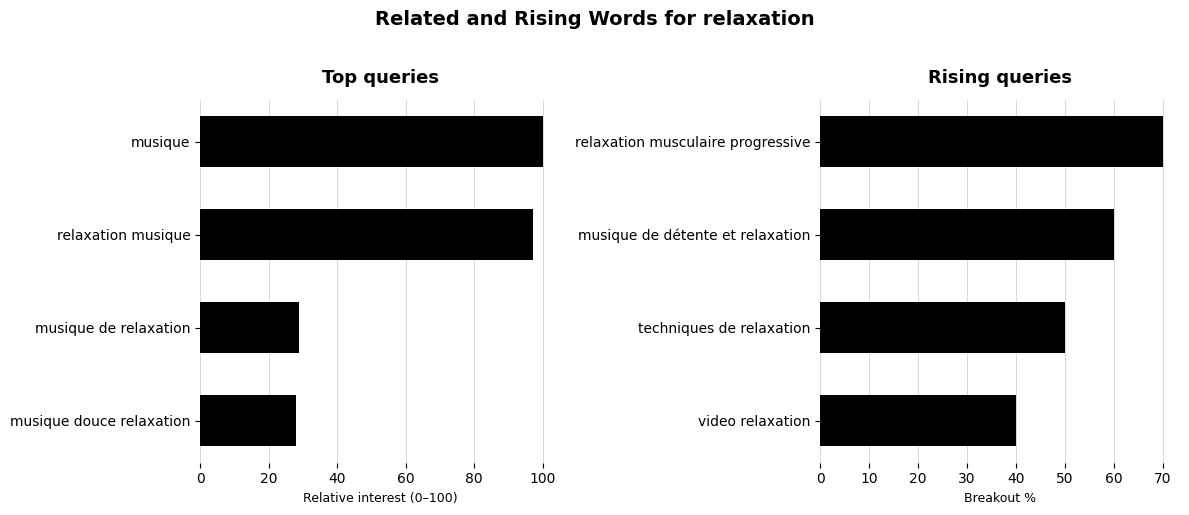

In [ ]:
# White background + black text/bars style

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 5), facecolor="white"
)

# Make axes backgrounds white
ax1.set_facecolor("white")
ax2.set_facecolor("white")

for ax, df, xlabel in [
    (ax1, top,    "Relative interest (0–100)"),
    (ax2, rising, "Breakout %"),
]:
    # Black bars
    ax.barh(
        df["query"][::-1],
        df["value"][::-1],
        color="black",
        height=0.55
    )

    # Labels and ticks in black
    ax.set_xlabel(xlabel, color="black", fontsize=9)
    ax.tick_params(axis="x", colors="black")
    ax.tick_params(axis="y", colors="black")

    # Remove borders
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Light gray grid
    ax.xaxis.grid(True, color="#d9d9d9", linewidth=0.7)

    ax.set_axisbelow(True)

# Titles in black
ax1.set_title(
    "Top queries",
    fontsize=13,
    fontweight="bold",
    color="black",
    pad=12
)

ax2.set_title(
    "Rising queries",
    fontsize=13,
    fontweight="bold",
    color="black",
    pad=12
)

# Main title
fig.suptitle(
    f"Related and Rising Words for {keyword_list[0]}",
    fontsize=14,
    fontweight="bold",
    color="black",
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "related_queries.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()